# **Project 2: Implementing Simple Linear Regression with Ordinary Least Squares (OLS) and Sum of Squared Errors (SSE) equations**

## **Objective**
In this assignment, you will implement simple linear regression from scratch using only NumPy and base Python. You will:

- Express linear regression in **matrix notation**.
- Compute the **line of best fit** using **OLS**.
- Calculate the **sum of squared errors (SSE)** to evaluate the model.

By the end of this assignment, you will understand how to derive and implement **linear regression** in its fundamental mathematical form.

---

## **Background**

### **Linear Regression Equation**
Simple linear regression is expressed as:


\begin{equation}
y = mx + b
\end{equation}


where:
- \( y \) is the **dependent variable** (target),
- \( x \) is the **independent variable** (feature),
- \( m \) is the **slope** (coefficient),
- \( b \) is the **y-intercept**.

---

### **Matrix Form**
We can express the equation in **matrix notation**:

\begin{equation}
Y = X \beta
\end{equation}

where:
- \$ Y \$ is an \$ n \times 1 \$ vector of observed values:

  \begin{aligned}
  Y =
  \begin{bmatrix}
  y_1 \\
  y_2 \\
  \vdots \\
  y_n
  \end{bmatrix}
  \end{aligned}

- \$ X \$ is an \$ n \times 2 \$ **design matrix**, where the first column consists of ones (for the intercept) and the second column contains the \$ x \$ values:

  \begin{aligned}
  X =
  \begin{bmatrix}
  1 & x_1 \\
  1 & x_2 \\
  \vdots & \vdots \\
  1 & x_n
  \end{bmatrix}
  \end{aligned}

- \$ \beta \$ is a \$ 2 \times 1 \$ vector containing the intercept \$( b \$) and slope \$( m \$):

  \begin{aligned}
  \beta =
  \begin{bmatrix}
  b \\
  m
  \end{bmatrix}
  \end{aligned}

Thus, our model can be rewritten as:

\begin{aligned}
\begin{bmatrix}
y_1 \\
y_2 \\
\vdots \\
y_n
\end{bmatrix}
&=
\begin{bmatrix}
1 & x_1 \\
1 & x_2 \\
\vdots & \vdots \\
1 & x_n
\end{bmatrix}
\begin{bmatrix}
b \\
m
\end{bmatrix}
\end{aligned}

---

### **Computing the Best Fit Line Using the ordinary least squares (OLS)**
The **best fit line** is obtained using the **ordinary least squares (OLS)**:

\begin{equation}
\beta = (X^T X)^{-1} X^T Y
\end{equation}

where:
- \$ X^T \$ is the transpose of \$ X \$,
- \$ (X^T X)^{-1} \$ is the **inverse** of \$ X^T X \$,
- \$ X^T Y \$ is the product of the transposed \$ X \$ and \$ Y \$.
---

### **Sum of Squared Errors (SSE)**
The **sum of squared errors (SSE)** is used to measure how well the regression line fits the data:


\begin{equation}
SSE = \frac{1}{n}\sum_{i=1}^{n} \|y_i - \hat{y}_i\|^2
\end{equation}

where:
- \$ y_i \$ represents the actual observed values,
- \$ \hat{y}_i \$ are the predicted values from the model.

Alternatively, using matrix notation:

\begin{equation}
SSE = (Y - X \beta)^T (Y - X \beta)
\end{equation}

where \$ Y - X\beta \$ represents the **residuals** (differences between actual and predicted values).

---

### **Coding**


###1. Import Required Libraries
For this lab only use NumPy, Pandas, Matplotlib, and base Python.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

###2. Data

* We have a data set that describes 506 suburbs in Boston. Find the documentation for the variables [here](https://islp.readthedocs.io/en/latest/datasets/Boston.html).
* *Goal*: Predict the median value (in $1000s) of houses owned in that suburb.
* *Task*: Use the covariates / indepednent variables from the data set to create 3 different types of predictive models: single variable, multivariable, and polynomial regression.

**First step: import the data, split into x and y, and turn them into numpy arrays.**

In [20]:
#https://islp.readthedocs.io/en/latest/datasets/Boston.html
df = pd.read_csv('https://raw.githubusercontent.com/intro-stat-learning/ISLP/refs/heads/main/ISLP/data/Boston.csv')
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [21]:
# remove the last column because we cannot use the dependent variable in the model
x = df.iloc[:, :-1]
x.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33


**Begin with a single variable model, selecting the 6th column: 'rm' (average number of rooms per dwelling)**

In [22]:
# Starting with single linear regression
x = df.iloc[:, 5:6]
x.head()

,rm
0,6.575
1,6.421
2,7.185
3,6.998
4,7.147


**Select the target variable that we want to predict: medv (median value of owner-occupied homes in $1000s)**

In [23]:
y = df.iloc[:, -1:]
y.head()

,medv
0,24.0
1,21.6
2,34.7
3,33.4
4,36.2


**Turn both data frame objects into numpy arrays.**

In [24]:
x = x.to_numpy()

In [25]:
y = y.to_numpy()

###3. Prepare Data in Matrix Form

#### 3a. Convert 𝑥 into matrix form by adding a column of ones for the intercept.

In [26]:
def prepare_matrix(x):
    n = len(x)
    X = np.column_stack((np.ones(n), x))  # Shape (n, 2)
    return X

X = prepare_matrix(x)
Y = y.reshape(-1, 1)  # Reshape y to column vector (aka. nx1 matrix)

#### 3b. Standardize the data. **(2 points)**

In [27]:
# insert your code for standardizing the data
# **remember that currently, your x variable is just the rm column, when you do question 7 and after, make sure every non-label column you use is also standardized**

x_mean = np.mean(x)
x_std = np.std(x)
x = (x - x_mean) / x_std

X = prepare_matrix(x)

#### 3c. *Why do we add a column of ones to the 𝑋 matrix?*  **(2 points)**

WE need to add a cloumn of ones to the X matrix so that that the regression model can correctly estimet that the variable b (intercept) would be. If this were not to be included the model would have to run through the orgin and could not learn the y axis intercept.

#### 3d. *Why do we need to standardize our data for linear regression?*  **(2 points)**

We beed to standardize our data for linear regression so that both of our variables are on the same scale, which allows the model to compute more effeicntyly so that the larger scales do not dominate the smaller/

#### 3e. *Why do we only standardize the 𝑋 matrix?* **(2 points)**

We only need to standarize the X matrix as it is our input variables which may be on a different scale while our Y matrix is our target, therefore being what we are tryign to predict so if we were to standaridize the y it would change the target numbers.

### 4. Compute the Best Fit Line Using OLS
#### 4a. Use the formula for Ordinary Least Squares (OLS) Regression to compute the $\beta$ vector. (Hint: Review Lab 4) **(2 points)**

In [28]:
# Compute beta vector

beta = np.linalg.inv(X.T @ X) @ X.T @ Y
print(beta)


[[22.53280632]
 [ 6.38897522]]


#### 4b. *Explain how OLS finds the line of best fit.* **(2 points)**

The OLS is able to find the line of best fit as it chooses different coefficients that are able to minimize the sum o rthe squarred differencted betwenn what the actual and predictied values are  so this is able to make a proper line that dits the data with small error.

###5. Using your computed values for $\beta$, generate the predicted values for the training data.
#### 5a. Use the computed $\beta$ to find the predictions $\hat{Y}$ using matrix multiplication with the design matrix X. **(2 points)**

In [29]:
# Create variable Y_pred (a list of predictions for each suburb)
def predict(X, beta):
    return X @ beta


#### *5b. What does the y_pred array respresent?* **(2 points)**


The y_pred represents represents the predicited value or the mudekls output, basedon the rarget vairabke that we gernreate from the regression model. 

### 6. Calculate the normalized Sum of Squared Errors (SSE) for the model.
#### 6a. Compute the SSE to measure how well the regression model fits the training data. **(2 points)**

> **Important:** In this assignment, whenever we say “SSE,” we mean the **normalized** version:
> \[
> \text{SSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat y_i)^2
> \]
> where \(n\) is the number of samples used in that SSE calculation (train or test). This makes train/test errors comparable even when the split sizes differ.


In [30]:
# Compute the **normalized** SSE (SSE/n) and store it in the variable `sse`.
# SSE = (1/n) * sum_i (y_i - yhat_i)^2, where n = number of samples used in this SSE.
# TODO: implement below

n = len(Y)
SSE = (1 / n) * np.sum((Y - predict(X, beta)) ** 2)


#### *6b. How does SSE relate to the goodness of fit of the model? In other words, what do we want SSE to be?* **(2 points)**


SSE is related to the goodness of the fit of the model as the SSE directly corlatted to the goodness, as the SSE increase, there less good the fit of the moder. In other words, we want the SSE to be as small as possible which would sigal a good model fit.

### 7. Visualize the resulting regression model and line of best fit. Plot the data alongside the line of best fit.

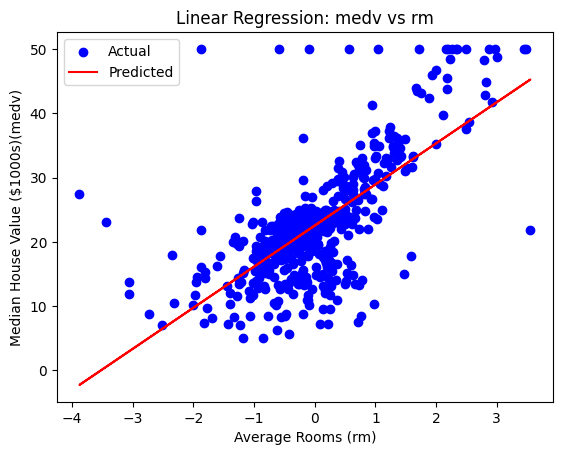

In [45]:
plt.scatter(x, y, color='blue', label='Actual')
plt.plot(x, predict(X, beta), color='red', label='Predicted')

plt.xlabel("Average Rooms (rm)")
plt.ylabel("Median House Value ($1000s)(medv)")
plt.title("Linear Regression: medv vs rm")

plt.legend()
plt.show()

### 8. The above plot looks at the relationship between *rm* (an independent variable) and *mdev* (the dependent variable we are trying to predict). Create a single ordinary least squares (OLS) regression with a different independent variable (other than *rm*) from our data set. Once you have your predictions, plot the line of best fit with your chosen independent variable on the x-axis and *mdev* on the y-axis. **(2 points)**

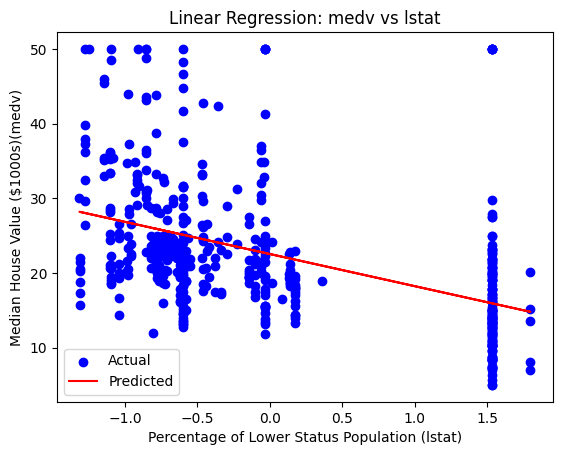

In [47]:
### implement your single regression model here

x = df.iloc[:, 9:10]
x = x.to_numpy()
x_mean = np.mean(x)
x_std = np.std(x)
x = (x - x_mean) / x_std
X = prepare_matrix(x)
beta = np.linalg.inv(X.T @ X) @ X.T @ Y

plt.scatter(x, y, color='blue', label='Actual')
plt.plot(x, predict(X, beta), color='red', label='Predicted')
plt.xlabel("Percentage of Lower Status Population (lstat)")
plt.ylabel("Median House Value ($1000s)(medv)")
plt.title("Linear Regression: medv vs lstat")
plt.legend()
plt.show()

### 9.
To this point, you've trained a single variable linear regression on just the training data. This tells us how the model will perform on data we already have, but not on actual data we recieve in the future. To get a better understanding of how the data will run on unseen data, we need to split our data into training and testing data.


Now, train a single linear regression model using a train/test split. Identify how the mdoel does on the training vs testing data.

#### 9a. Split the data into a training and test split. In the training set, keep 80% of the observations. In the test set, keep the other 20% of observations. **(2 points)**

In [50]:
# Split into Training and Testing Sets (80% of the data should be in your training array and 20% of your data should be in your test array)
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

#### 9b. With your training data, train the model by minimizing the Sum of Squared Errors (normalized SSE (SSE/n)). You will have one coefficient for the intercept term $(\beta_0)$ and another for your chosen independent variable ($\beta_1$). **(10 points)**

> Reminder: use **SSE = (1/n)·∑(y-ŷ)^2** with n equal to the sample size for that split.


In [51]:
# Train model by minimizing the (normalized) SSE.
# Note: dividing SSE by n does NOT change the optimal coefficients (it only rescales the objective).
# TODO: implement training below

beta_train = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ Y_train


#### 9c. Using your trained model ($\beta$ coefficients), calculate your predictions on the training data set. Compare your predictions with the true values of *mdev* in the train set by computing the normalized SSE (SSE/n). Report your value of normalized SSE (SSE/n). **(5 points)**

> Reminder: use **SSE = (1/n)·∑(y-ŷ)^2** with n equal to the sample size for that split.


In [56]:
# Evaluate your trained model on the training data.
# Compute the **normalized** SSE (SSE/n) on the TRAIN split.
# TODO: compute sse_train below

yhat_train = predict(X_train, beta)
n_train = len(Y_train)
sse_train = (1 / n_train) * np.sum((Y_train - yhat_train) ** 2)
print(sse_train)



68.53356499034464


#### 9d. Now use your trained model to calculate your predictions on the test data set. Compute the normalized SSE (SSE/n) on the test data set. **(5 points)**

> Reminder: use **SSE = (1/n)·∑(y-ŷ)^2** with n equal to the sample size for that split.


In [57]:
# Evaluate your trained model on the test data.
# Compute the **normalized** SSE (SSE/n) on the TEST split.
# TODO: compute sse_test below

yhat_test = predict(X_test, beta)

n = len(Y_test)
sse_test = (1 / n) * np.sum((Y_test - yhat_test) ** 2)

print(sse_test)


55.40589278766044


#### 9e. How does the SSE on the test set compare to the SSE on the training set? **(2 points)**

The SSE on the training set it lower than that off the testing



### 9f. Plot (like in Question 7) your line of best fit over your training data. **(2 points)**

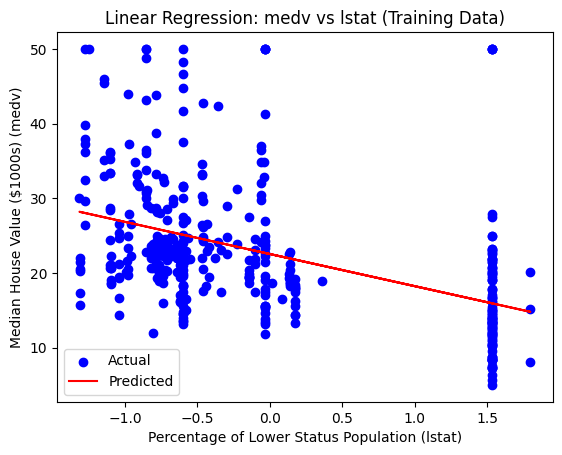

In [61]:
# Plot here

plt.scatter(X_train[:,1], Y_train, color='blue', label='Actual')
plt.plot(X_train[:,1], predict(X_train, beta), color='red', label='Predicted')

plt.xlabel("Percentage of Lower Status Population (lstat)")
plt.ylabel("Median House Value ($1000s) (medv)")
plt.title("Linear Regression: medv vs lstat (Training Data)")

plt.legend()
plt.show()

### 9g. Plot (like in Question 7) your line of best fit over your test data. **(2 points)**

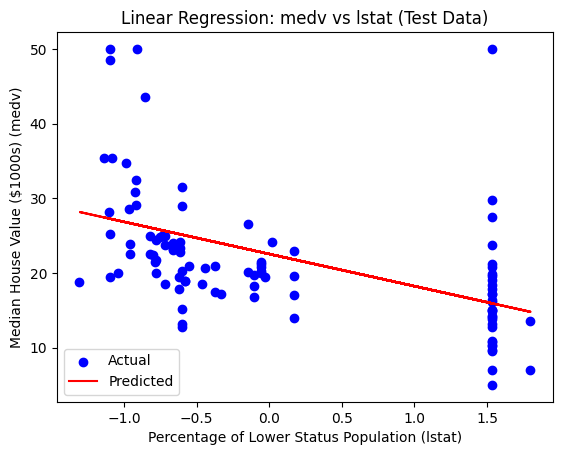

In [60]:
# Plot here

plt.scatter(X_test[:,1], Y_test, color='blue', label='Actual')
plt.plot(X_test[:,1], predict(X_test, beta), color='red', label='Predicted')

plt.xlabel("Percentage of Lower Status Population (lstat)")
plt.ylabel("Median House Value ($1000s) (medv)")
plt.title("Linear Regression: medv vs lstat (Test Data)")

plt.legend()
plt.show()



### 10. The models you have created thus far are only examples of single ordinary least squares. What if we want to include more than one independent variable in our prediction? Train a multiple linear regression model which incorporates all of the available independent variables in the data set. Using your model, predict the median house value. Compare your results on the training data set vs the test data set again. **(10 points)**

> Reminder: when comparing train vs test error, use **normalized SSE = (1/n)·∑(y-ŷ)^2**.


In [62]:
### Modify your code for multiple linear regression (use all non-label columns available to train a model to predict median house value)
#Hint: remove the last column because we cannot use the dependent variable in the model


x = df.iloc[:, :-1]
x = x.to_numpy()

x_mean = np.mean(x)
x_std = np.std(x)
x = (x - x_mean) / x_std
X = np.column_stack((np.ones(len(x)), x))
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
beta = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ Y_train
yhat_train = predict(X_train, beta)

sse_train = np.sum((Y_train - yhat_train)**2) / len(Y_train)

print( sse_train)
yhat_test = predict(X_test, beta)

sse_test = np.sum((Y_test - yhat_test)**2) / len(Y_test)

print( sse_test)

22.604286479417404
22.777708562374254


### 11. The model you made in the previous question only had linear terms of our features. Sometimes, we want to capture more complicated relationships between variables. To add more complexity to our model, experiment with differnet polynomial models. For each model, try to think about whether you may be overfitting or underfitting to the training data. Again, compare your performnance on the training data vs the testing data.

#### 11a. Modify the design matrix to include polynomial terms of degree 2. (Hint: add squared values of existing columns to the deign matrix X). Calculate the normalized SSE (SSE/n) on the training and testing data sets. **(10 points)**

> Reminder: use **SSE = (1/n)·∑(y-ŷ)^2** with n equal to the sample size for that split.


In [63]:
### Modify for polynomial regression (degree 2)
# Reminder: when reporting SSE in this section, use **normalized SSE** = sum((y - yhat)^2) / n.
# TODO: build your degree-2 design matrix, fit coefficients, and compute train/test normalized SSE.


# all independent variables
x = df.iloc[:, :-1].to_numpy()
Y = df.iloc[:, -1:].to_numpy()

# standardize each feature column
x_mean = np.mean(x, axis=0)
x_std = np.std(x, axis=0)
x = (x - x_mean) / x_std

# degree-2 design matrix: [1, x, x^2]
X_poly = np.column_stack((np.ones(len(x)), x, x**2))

# split data
X_train, X_test, Y_train, Y_test = train_test_split(X_poly, Y, test_size=0.2, random_state=42)

# fit degree-2 model with OLS
beta = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ Y_train

# predictions
yhat_train = predict(X_train, beta)
yhat_test = predict(X_test, beta)

# normalized SSE
sse_train = np.sum((Y_train - yhat_train) ** 2) / len(Y_train)
sse_test = np.sum((Y_test - yhat_test) ** 2) / len(Y_test)

print("Training SSE:", sse_train)
print("Test SSE:", sse_test)

Training SSE: 15.052572373720473
Test SSE: 13.1623110783279


#### 11aa. After fitting your degree-2 model, make a quick visualization for sanity-checking. **(5 points)**

Using the **same single feature** you used back in Q9 (your chosen independent variable), plot:
1. The original data points \((x, y)\) as a scatter plot.
2. The fitted quadratic curve \(\hat{y} = a + bx + cx^2\) on top of the scatter plot.

> Tip: sort the x-values before plotting the curve so the line looks smooth.



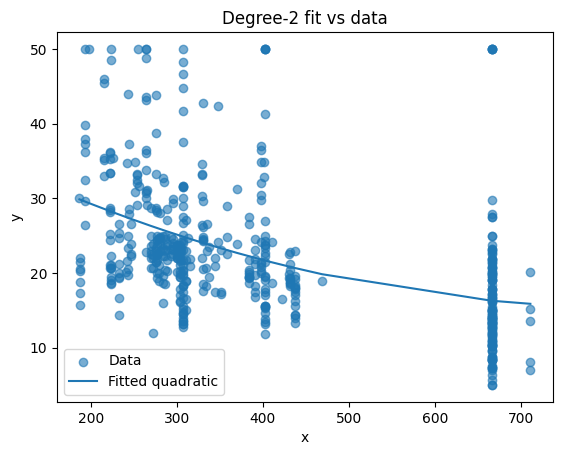

In [68]:
# 11aa: Plot datapoints and fitted quadratic yhat = a + b x + c x^2 (for your chosen feature from Q9)
# TODO: Fill in `x_feature`, `y_true`, and the coefficients a, b, c from your degree-2 fit.

import numpy as np
import matplotlib.pyplot as plt

x_feature = df["tax"].to_numpy()
y_true = df["medv"].to_numpy()

X_quad = np.column_stack((np.ones(len(x_feature)), x_feature, x_feature**2))

beta = np.linalg.inv(X_quad.T @ X_quad) @ X_quad.T @ y_true

a = beta[0]
b = beta[1]
c = beta[2]


# Make a smooth curve
x_sorted = np.sort(x_feature)
y_curve = a + b * x_sorted + c * (x_sorted ** 2)

plt.figure()
plt.scatter(x_feature, y_true, alpha=0.6, label="Data")
plt.plot(x_sorted, y_curve, label="Fitted quadratic")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Degree-2 fit vs data")
plt.legend()
plt.show()



#### 11b. To test how our model performs as we change the degree of our model. Train models of degree 1 to degree 8. This will result in 8 different models.  For each model you create, save the Sum of Squared Errors (normalized SSE (SSE/n)) on the training and test data set respectively. We will use them for the next step to plot how they change as the model becomes more complex. **(20 points)**

> Reminder: use **SSE = (1/n)·∑(y-ŷ)^2** with n equal to the sample size for that split.


In [70]:
### Fit polynomial models of degrees 1-8, save training and testing errors
# Reminder: store **normalized** SSE values for each split:
#   sse_k_train = sum((y_train - yhat_train)^2) / len(y_train)
#   sse_k_test  = sum((y_test  - yhat_test )^2) / len(y_test)
# TODO: implement loop over degrees below and save errors for plotting.

train_errors = []
test_errors = []

# same single feature from Q9
x_feature = df["tax"].to_numpy()
y_true = df["medv"].to_numpy()

# split the single feature and target
x_train, x_test, y_train, y_test = train_test_split(
    x_feature, y_true, test_size=0.2, random_state=42
)

for degree in range(1, 9):
    # build polynomial design matrices
    X_train_poly = np.column_stack([x_train**d for d in range(degree + 1)])
    X_test_poly = np.column_stack([x_test**d for d in range(degree + 1)])

    # fit model on training data
    beta = np.linalg.inv(X_train_poly.T @ X_train_poly) @ X_train_poly.T @ y_train

    # predictions
    yhat_train = X_train_poly @ beta
    yhat_test = X_test_poly @ beta

    # normalized SSE
    sse_train = np.sum((y_train - yhat_train) ** 2) / len(y_train)
    sse_test = np.sum((y_test - yhat_test) ** 2) / len(y_test)

    train_errors.append(sse_train)
    test_errors.append(sse_test)

print("Train errors:", train_errors)
print("Test errors:", test_errors)


Train errors: [np.float64(68.5073893066988), np.float64(68.36821795975806), np.float64(68.36822070333446), np.float64(68.51336030682522), np.float64(167.31873060521042), np.float64(5540718.5152218025), np.float64(4.57710032110817e+42), np.float64(1.2583744781328164e+43)]
Test errors: [np.float64(55.63802986480272), np.float64(54.443814953474224), np.float64(54.443833035478946), np.float64(55.66537183599113), np.float64(165.46229965128356), np.float64(7148343.566449106), np.float64(4.8264769694304636e+42), np.float64(9.316965913760348e+42)]


### Overfitting

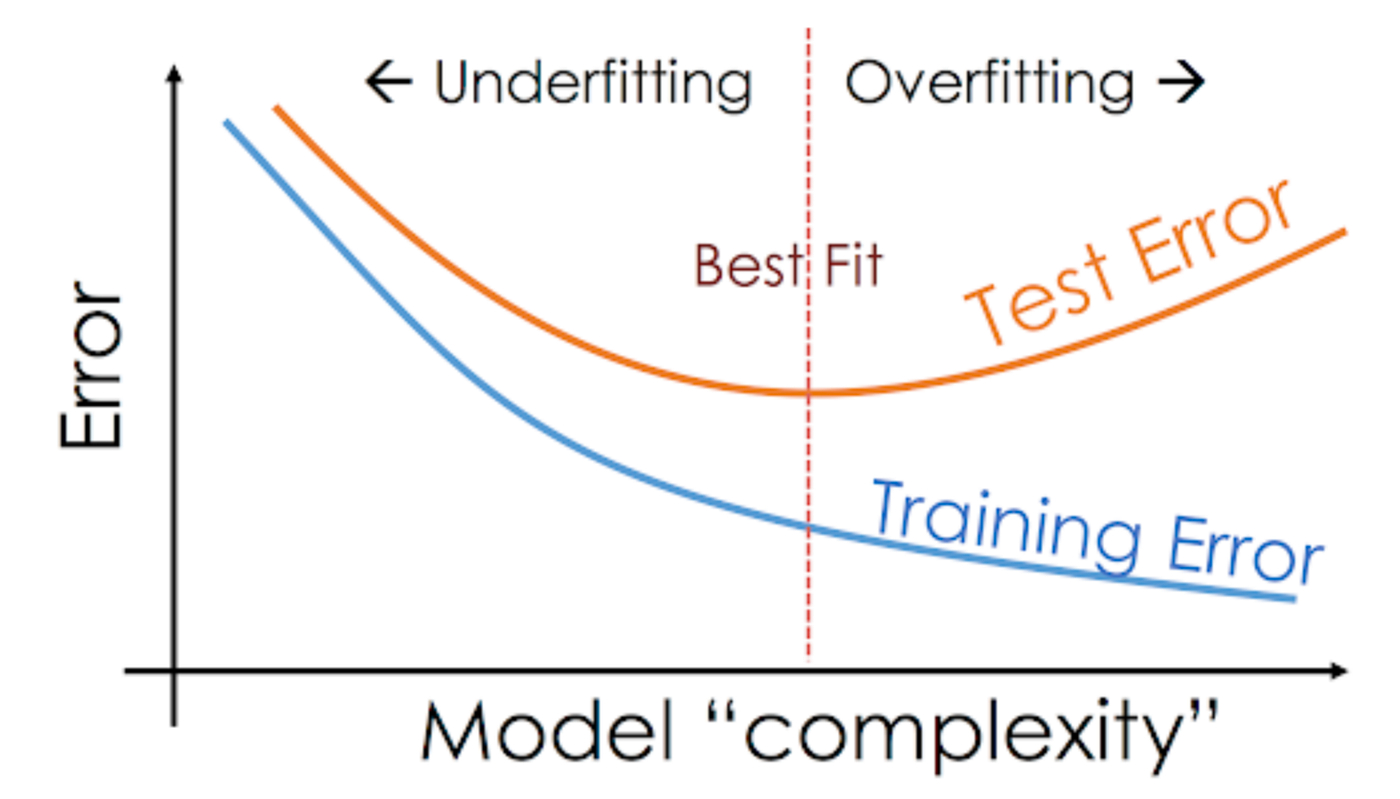

#### 11c. Using the training and testing normalized SSE (SSE/n) you calculated in the previous question, plot the errors for each model complexity. In this plot, the x-axis will be the model complexity (degree of the model) and the y-axis will be the normalized SSE (SSE/n) you calculated. What can you determine from this plot? How does the error on the training data set compare to the error on the testing data set as the degree of the model increases? **(10 points)**

> Reminder: use **SSE = (1/n)·∑(y-ŷ)^2** with n equal to the sample size for that split.


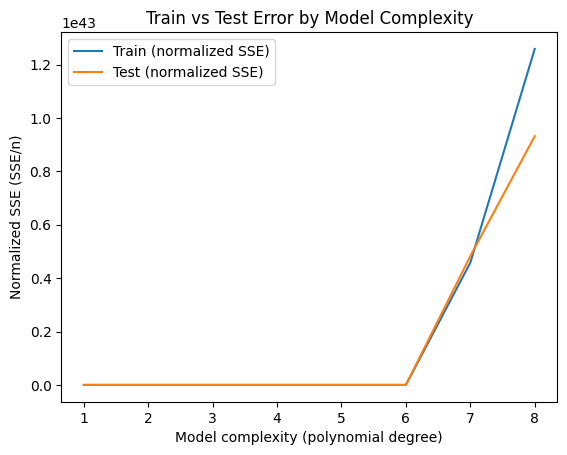

In [71]:
###Graph training and testing errors on same line plot to show overfitting
#After you correct SSE everywhere (use normalized SSE), make sure this plot renders and matches the reference image above.
#TODO: replace `degrees`, `train_errors`, `test_errors` with your actual arrays/lists.

import matplotlib.pyplot as plt

# Example placeholders (replace with your computed values)
degrees = list(range(1, 9))
# train_errors = [...]
# test_errors = [...]

plt.figure()
plt.plot(degrees, train_errors, label="Train (normalized SSE)")
plt.plot(degrees, test_errors, label="Test (normalized SSE)")
plt.xlabel("Model complexity (polynomial degree)")
plt.ylabel("Normalized SSE (SSE/n)")
plt.title("Train vs Test Error by Model Complexity")
plt.legend()
plt.show()

